In [1]:
import os
import json
import time
import pickle
from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score,
    accuracy_score, roc_auc_score, average_precision_score
)

import lightgbm as lgb

import warnings
warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("Setup complete.")

Setup complete.


In [5]:
data_dir = Path("/home/mini/projects/review-intelligence-system/data/processed")

train_clean = pd.read_parquet(data_dir / "train.parquet")
val_clean = pd.read_parquet(data_dir / "val.parquet")
test_clean = pd.read_parquet(data_dir / "test.parquet")

clean_df = pd.concat([train_clean, val_clean, test_clean], ignore_index=True)

duplicates_df = pd.read_csv(data_dir / "text_duplicates_for_fake_detection.csv")

import re
def clean_text(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

duplicates_df['text_clean'] = duplicates_df['text'].apply(clean_text)
duplicates_df['word_count_clean'] = duplicates_df['text_clean'].str.split().str.len()

print(f"Clean reviews (genuine pool): {len(clean_df):,}")
print(f"Text duplicates (suspected fake): {len(duplicates_df):,}")
print(f"\nClean reviews columns: {clean_df.columns.tolist()}")
print(f"Duplicates columns: {duplicates_df.columns.tolist()}")


Clean reviews (genuine pool): 89,021
Text duplicates (suspected fake): 4,666

Clean reviews columns: ['rating', 'title', 'text', 'text_clean', 'word_count_clean', 'sentiment', 'category', 'verified_purchase', 'helpful_vote', 'user_id', 'asin', 'timestamp']
Duplicates columns: ['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase', 'category', 'text_length', 'word_count', 'datetime', 'review_year', 'review_month', 'text_clean', 'word_count_clean']


In [6]:
print("="*60)
print("WEAK LABEL STRATEGY")
print("="*60)
print("""
Definition:
  fake_score = 1 (suspected fake) if at least 2 conditions met:
  
  Strong signals (each = 2 points):
  - Text appears > 5 times across users (template pattern)
  - Generic short text (< 5 words AND in top common phrases)
  - Verified=False AND rating in [1, 5] (extreme rating)
  
  Medium signals (each = 1 point):
  - Same user posted same/similar text multiple times
  - Rating-text sentiment mismatch
  - Helpful_vote=0 AND rating in [1, 5] AND text length < 30
  
  Threshold: total points >= 3 → label as suspected fake
""")


WEAK LABEL STRATEGY

Definition:
  fake_score = 1 (suspected fake) if at least 2 conditions met:
  
  Strong signals (each = 2 points):
  - Text appears > 5 times across users (template pattern)
  - Generic short text (< 5 words AND in top common phrases)
  - Verified=False AND rating in [1, 5] (extreme rating)
  
  Medium signals (each = 1 point):
  - Same user posted same/similar text multiple times
  - Rating-text sentiment mismatch
  - Helpful_vote=0 AND rating in [1, 5] AND text length < 30
  
  Threshold: total points >= 3 → label as suspected fake



In [7]:
df = clean_df.copy()

generic_phrases = {
    'good', 'great', 'love it', 'good product', 'great product',
    'excellent', 'works great', 'nice', 'ok', 'okay',
    'five stars', 'amazing', 'perfect', 'awesome'
}

df['signal_generic_short'] = (
    (df['word_count_clean'] < 5) & 
    (df['text_clean'].str.lower().str.strip().isin(generic_phrases))
).astype(int) * 2

print(f"Signal 1 (generic short): {df['signal_generic_short'].sum():,} reviews flagged")

df['signal_unverified_extreme'] = (
    (~df['verified_purchase']) & 
    (df['rating'].isin([1.0, 5.0]))
).astype(int) * 2

print(f"Signal 2 (unverified extreme rating): {df['signal_unverified_extreme'].sum():,} reviews flagged")

user_review_counts = df['user_id'].value_counts()
prolific_users = set(user_review_counts[user_review_counts >= 10].index)

df['signal_prolific_user'] = df['user_id'].isin(prolific_users).astype(int) * 1

print(f"Signal 3 (prolific users, 10+ reviews): {df['signal_prolific_user'].sum():,} reviews flagged")

df['signal_unhelpful_extreme_short'] = (
    (df['helpful_vote'] == 0) & 
    (df['rating'].isin([1.0, 5.0])) & 
    (df['word_count_clean'] < 15)
).astype(int) * 1

print(f"Signal 4 (unhelpful extreme short): {df['signal_unhelpful_extreme_short'].sum():,} reviews flagged")

df['fake_score'] = (
    df['signal_generic_short'] + 
    df['signal_unverified_extreme'] + 
    df['signal_prolific_user'] +
    df['signal_unhelpful_extreme_short']
)

print(f"\nFake score distribution:")
print(df['fake_score'].value_counts().sort_index())

Signal 1 (generic short): 0 reviews flagged
Signal 2 (unverified extreme rating): 35,718 reviews flagged
Signal 3 (prolific users, 10+ reviews): 50,088 reviews flagged
Signal 4 (unhelpful extreme short): 10,716 reviews flagged

Fake score distribution:
fake_score
0    29022
1    38958
2     5836
3    14928
4      277
Name: count, dtype: int64


In [8]:
FAKE_THRESHOLD = 3

df['weak_label_fake'] = (df['fake_score'] >= FAKE_THRESHOLD).astype(int)

print(f"Threshold: fake_score >= {FAKE_THRESHOLD}")
print(f"Suspected fake (from clean pool): {df['weak_label_fake'].sum():,} ({df['weak_label_fake'].mean()*100:.2f}%)")
print(f"Genuine: {(df['weak_label_fake']==0).sum():,}")

Threshold: fake_score >= 3
Suspected fake (from clean pool): 15,205 (17.08%)
Genuine: 73,816


In [9]:
duplicates_df['weak_label_fake'] = 1
duplicates_df['fake_score'] = 4  # high confidence

common_cols = ['rating', 'title', 'text', 'text_clean', 'word_count_clean',
               'category', 'verified_purchase', 'helpful_vote',
               'user_id', 'asin', 'timestamp', 'weak_label_fake', 'fake_score']

for col in common_cols:
    if col not in duplicates_df.columns:
        if col in ['signal_generic_short', 'signal_unverified_extreme', 
                   'signal_prolific_user', 'signal_unhelpful_extreme_short']:
            duplicates_df[col] = 0
        elif col == 'sentiment':
            from sklearn.preprocessing import LabelEncoder
            # Won't be used here, skip
            duplicates_df[col] = 'unknown'



df_clean_subset = df[common_cols].copy()
df_dup_subset = duplicates_df[common_cols].copy()

df_combined = pd.concat([df_clean_subset, df_dup_subset], ignore_index=True)

print(f"Combined dataset:")
print(f"  Total: {len(df_combined):,}")
print(f"  Suspected fake: {df_combined['weak_label_fake'].sum():,} ({df_combined['weak_label_fake'].mean()*100:.2f}%)")
print(f"  Genuine: {(df_combined['weak_label_fake']==0).sum():,}")
print(f"\nCombined columns: {df_combined.columns.tolist()}")


Combined dataset:
  Total: 93,687
  Suspected fake: 19,871 (21.21%)
  Genuine: 73,816

Combined columns: ['rating', 'title', 'text', 'text_clean', 'word_count_clean', 'category', 'verified_purchase', 'helpful_vote', 'user_id', 'asin', 'timestamp', 'weak_label_fake', 'fake_score']


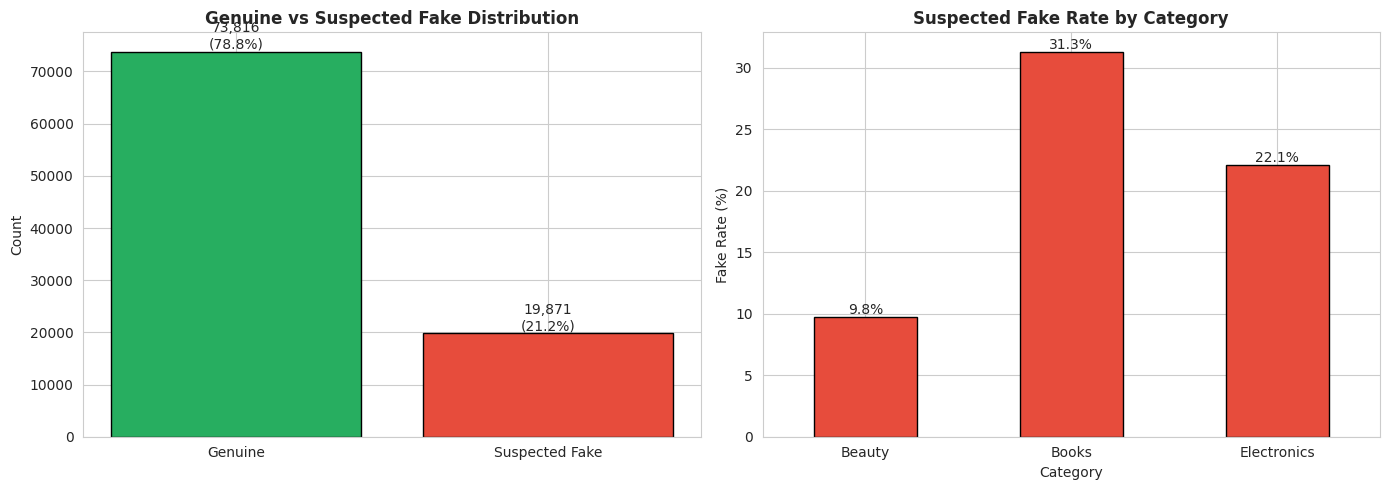

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
counts = df_combined['weak_label_fake'].value_counts()
labels = ['Genuine', 'Suspected Fake']
colors = ['#27ae60', '#e74c3c']
ax.bar(labels, [counts[0], counts[1]], color=colors, edgecolor='black')
ax.set_title('Genuine vs Suspected Fake Distribution', fontweight='bold')
ax.set_ylabel('Count')
for i, v in enumerate([counts[0], counts[1]]):
    ax.text(i, v, f'{v:,}\n({v/len(df_combined)*100:.1f}%)', 
            ha='center', va='bottom')

ax = axes[1]
fake_by_cat = df_combined.groupby('category')['weak_label_fake'].agg(['sum', 'count'])
fake_by_cat['pct'] = fake_by_cat['sum'] / fake_by_cat['count'] * 100
fake_by_cat['pct'].plot(kind='bar', ax=ax, color='#e74c3c', edgecolor='black')
ax.set_title('Suspected Fake Rate by Category', fontweight='bold')
ax.set_ylabel('Fake Rate (%)')
ax.set_xlabel('Category')
ax.tick_params(axis='x', rotation=0)
for i, v in enumerate(fake_by_cat['pct'].values):
    ax.text(i, v, f'{v:.1f}%', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('../reports/figures/10_fake_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

In [11]:
print("Preparing features for supervised classifier...")

tfidf = TfidfVectorizer(
    max_features=30_000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    strip_accents='unicode',
    lowercase=True
)

metadata_cols = ['rating', 'helpful_vote', 'word_count_clean']
df_combined['verified_purchase_int'] = df_combined['verified_purchase'].astype(int)
metadata_cols.append('verified_purchase_int')

X_text = df_combined['text_clean'].values
X_meta = df_combined[metadata_cols].values
y = df_combined['weak_label_fake'].values

X_text_train, X_text_test, X_meta_train, X_meta_test, y_train, y_test = train_test_split(
    X_text, X_meta, y, 
    test_size=0.2, 
    random_state=RANDOM_SEED, 
    stratify=y
)

print(f"Train: {len(y_train):,} (fake rate: {y_train.mean()*100:.2f}%)")
print(f"Test:  {len(y_test):,} (fake rate: {y_test.mean()*100:.2f}%)")

Preparing features for supervised classifier...
Train: 74,949 (fake rate: 21.21%)
Test:  18,738 (fake rate: 21.21%)


In [12]:
print("Fitting TF-IDF...")
X_text_train_tfidf = tfidf.fit_transform(X_text_train)
X_text_test_tfidf = tfidf.transform(X_text_test)

print(f"TF-IDF shape: {X_text_train_tfidf.shape}")

# Scale metadata
scaler = StandardScaler()
X_meta_train_scaled = scaler.fit_transform(X_meta_train)
X_meta_test_scaled = scaler.transform(X_meta_test)

# Combine sparse TF-IDF + dense metadata
from scipy.sparse import hstack, csr_matrix
X_train_full = hstack([X_text_train_tfidf, csr_matrix(X_meta_train_scaled)])
X_test_full = hstack([X_text_test_tfidf, csr_matrix(X_meta_test_scaled)])

print(f"Combined feature shape: {X_train_full.shape}")

Fitting TF-IDF...
TF-IDF shape: (74949, 30000)
Combined feature shape: (74949, 30004)


In [13]:
print("Training LightGBM classifier...")
start = time.time()

lgb_clf = lgb.LGBMClassifier(
    objective='binary',
    metric='binary_logloss',
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=5,
    class_weight='balanced',
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbose=-1
)

lgb_clf.fit(X_train_full, y_train)
print(f"LightGBM trained in {time.time() - start:.1f}s")

y_pred_lgb = lgb_clf.predict(X_test_full)
y_pred_lgb_proba = lgb_clf.predict_proba(X_test_full)[:, 1]

Training LightGBM classifier...
LightGBM trained in 179.0s


In [14]:
def evaluate_binary_classifier(y_true, y_pred, y_pred_proba, model_name):
    print(f"\n{'='*60}")
    print(f"  {model_name}")
    print(f"{'='*60}")
    
    print(f"Accuracy:        {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision:       {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:          {recall_score(y_true, y_pred):.4f}")
    print(f"F1:              {f1_score(y_true, y_pred):.4f}")
    print(f"ROC-AUC:         {roc_auc_score(y_true, y_pred_proba):.4f}")
    print(f"PR-AUC:          {average_precision_score(y_true, y_pred_proba):.4f}")
    
    print(f"\nClassification Report:")
    print(classification_report(y_true, y_pred, 
                                target_names=['Genuine', 'Fake'], 
                                digits=4))
    
    return {
        'model': model_name,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
        'roc_auc': roc_auc_score(y_true, y_pred_proba),
        'pr_auc': average_precision_score(y_true, y_pred_proba)
    }


lgb_results = evaluate_binary_classifier(
    y_test, y_pred_lgb, y_pred_lgb_proba,
    "Supervised: LightGBM (TF-IDF + Metadata)"
)


  Supervised: LightGBM (TF-IDF + Metadata)
Accuracy:        0.9705
Precision:       0.8899
Recall:          0.9824
F1:              0.9339
ROC-AUC:         0.9940
PR-AUC:          0.9815

Classification Report:
              precision    recall  f1-score   support

     Genuine     0.9951    0.9673    0.9810     14764
        Fake     0.8899    0.9824    0.9339      3974

    accuracy                         0.9705     18738
   macro avg     0.9425    0.9748    0.9574     18738
weighted avg     0.9728    0.9705    0.9710     18738



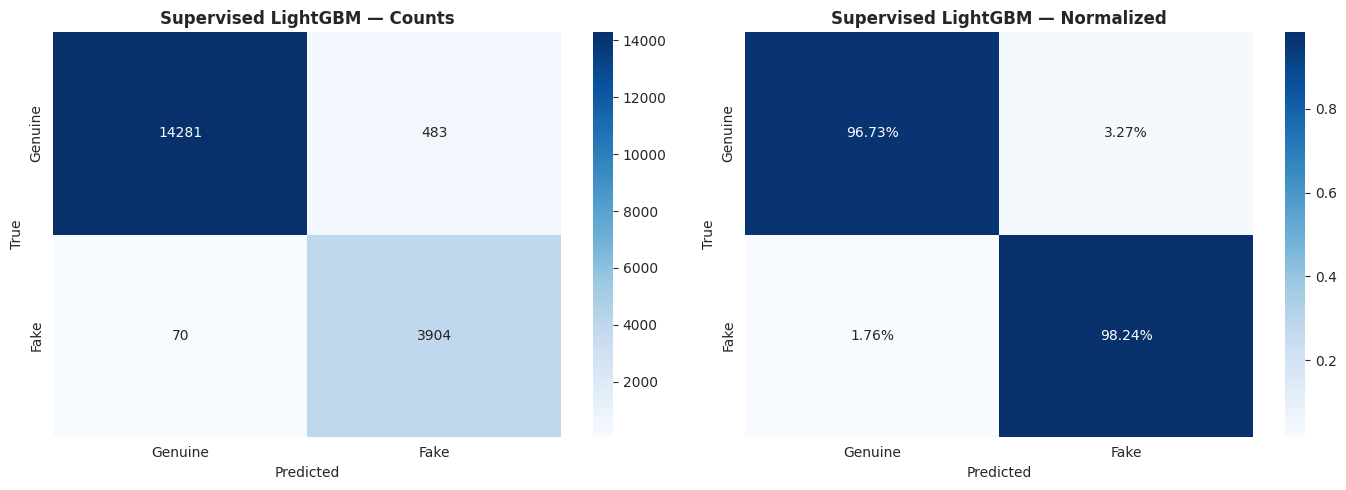

In [15]:
cm = confusion_matrix(y_test, y_pred_lgb)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Genuine', 'Fake'], yticklabels=['Genuine', 'Fake'],
            ax=axes[0])
axes[0].set_title('Supervised LightGBM — Counts', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=['Genuine', 'Fake'], yticklabels=['Genuine', 'Fake'],
            ax=axes[1])
axes[1].set_title('Supervised LightGBM — Normalized', fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.savefig('../reports/figures/11_supervised_fake_confusion.png', dpi=100, bbox_inches='tight')
plt.show()

In [16]:
# We'll use TF-IDF (already fitted) as embeddings for simplicity
# In production, sentence-BERT would be better but slower

# For faster computation, we'll use a sample
SAMPLE_SIZE = 20_000  # full ~94K is too slow for IsolationForest
print(f"Sampling {SAMPLE_SIZE:,} reviews for anomaly detection...")

sample_indices = np.random.choice(len(df_combined), SAMPLE_SIZE, replace=False)
sample_df = df_combined.iloc[sample_indices].copy().reset_index(drop=True)

# Create features for anomaly detection
sample_text = sample_df['text_clean'].values
sample_text_tfidf = tfidf.transform(sample_text)

# Reduce dimensions for IsolationForest (it's slow on high-dim sparse data)
from sklearn.decomposition import TruncatedSVD
print("Reducing TF-IDF dimensions with SVD...")
svd = TruncatedSVD(n_components=50, random_state=RANDOM_SEED)
sample_text_dense = svd.fit_transform(sample_text_tfidf)

# Add metadata features
sample_df['verified_purchase_int'] = sample_df['verified_purchase'].astype(int)
sample_meta = sample_df[metadata_cols].values
sample_meta_scaled = scaler.transform(sample_meta)

# Combine
sample_features = np.hstack([sample_text_dense, sample_meta_scaled])
print(f"Final features shape: {sample_features.shape}")

Sampling 20,000 reviews for anomaly detection...
Reducing TF-IDF dimensions with SVD...
Final features shape: (20000, 54)


In [17]:
print("Training Isolation Forest...")
start = time.time()

# Contamination = expected proportion of outliers (use observed fake rate)
fake_rate = sample_df['weak_label_fake'].mean()
print(f"Setting contamination to observed fake rate: {fake_rate:.3f}")

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=fake_rate,
    random_state=RANDOM_SEED,
    n_jobs=-1
)

# Fit on all sample data (unsupervised)
iso_forest.fit(sample_features)

# Predictions: -1 = outlier (fake), 1 = inlier (genuine)
sample_df['iso_prediction'] = iso_forest.predict(sample_features)
sample_df['iso_score'] = -iso_forest.decision_function(sample_features)  # higher = more anomalous

# Convert to binary: 1 = fake, 0 = genuine
sample_df['iso_pred_fake'] = (sample_df['iso_prediction'] == -1).astype(int)

print(f"Isolation Forest trained in {time.time() - start:.1f}s")
print(f"\nIsolation Forest predictions:")
print(f"  Predicted fake: {sample_df['iso_pred_fake'].sum():,} ({sample_df['iso_pred_fake'].mean()*100:.2f}%)")

Training Isolation Forest...
Setting contamination to observed fake rate: 0.211
Isolation Forest trained in 0.8s

Isolation Forest predictions:
  Predicted fake: 4,219 (21.09%)


In [18]:
y_sample_true = sample_df['weak_label_fake'].values
y_sample_iso = sample_df['iso_pred_fake'].values
iso_scores = sample_df['iso_score'].values

iso_results = evaluate_binary_classifier(
    y_sample_true, y_sample_iso, iso_scores,
    "Unsupervised: Isolation Forest"
)


  Unsupervised: Isolation Forest
Accuracy:        0.7037
Precision:       0.2977
Recall:          0.2977
F1:              0.2977
ROC-AUC:         0.5811
PR-AUC:          0.3442

Classification Report:
              precision    recall  f1-score   support

     Genuine     0.8122    0.8122    0.8122     15781
        Fake     0.2977    0.2977    0.2977      4219

    accuracy                         0.7037     20000
   macro avg     0.5550    0.5550    0.5550     20000
weighted avg     0.7037    0.7037    0.7037     20000



In [19]:
print("Creating hybrid model: weighted average of supervised and unsupervised scores...")

# We need both predictions on the same set
# Use the test set from supervised approach, predict with iso_forest on those
# But iso_forest was fit on different data — we'll predict on test set fresh

# Re-prepare test features for iso_forest
X_text_test_tfidf_dense = svd.transform(X_text_test_tfidf)
X_test_iso_features = np.hstack([X_text_test_tfidf_dense, X_meta_test_scaled])

iso_test_scores = -iso_forest.decision_function(X_test_iso_features)

# Normalize both to 0-1 range
from sklearn.preprocessing import MinMaxScaler
scaler01 = MinMaxScaler()
lgb_scores_norm = y_pred_lgb_proba  # already 0-1
iso_scores_norm = scaler01.fit_transform(iso_test_scores.reshape(-1, 1)).flatten()

# Weighted hybrid (60% supervised, 40% unsupervised)
ALPHA = 0.6
hybrid_scores = ALPHA * lgb_scores_norm + (1 - ALPHA) * iso_scores_norm
hybrid_pred = (hybrid_scores >= 0.5).astype(int)

# Evaluate hybrid
hybrid_results = evaluate_binary_classifier(
    y_test, hybrid_pred, hybrid_scores,
    f"Hybrid: {ALPHA*100:.0f}% Supervised + {(1-ALPHA)*100:.0f}% Unsupervised"
)

Creating hybrid model: weighted average of supervised and unsupervised scores...

  Hybrid: 60% Supervised + 40% Unsupervised
Accuracy:        0.9716
Precision:       0.9061
Recall:          0.9663
F1:              0.9352
ROC-AUC:         0.9921
PR-AUC:          0.9727

Classification Report:
              precision    recall  f1-score   support

     Genuine     0.9908    0.9730    0.9818     14764
        Fake     0.9061    0.9663    0.9352      3974

    accuracy                         0.9716     18738
   macro avg     0.9484    0.9697    0.9585     18738
weighted avg     0.9728    0.9716    0.9719     18738



In [ ]:
all_results = pd.DataFrame([lgb_results, iso_results, hybrid_results])
print("="*80)
print("FAKE REVIEW DETECTION — APPROACH COMPARISON")
print("="*80)
print(all_results.to_string(index=False))

md_table = all_results.to_markdown(index=False, floatfmt=".4f")
print("\nMarkdown:")
print(md_table)

FAKE REVIEW DETECTION — APPROACH COMPARISON
                                    model  accuracy  precision   recall       f1  roc_auc   pr_auc
 Supervised: LightGBM (TF-IDF + Metadata)  0.970488   0.889902 0.982386 0.933860 0.994015 0.981466
           Unsupervised: Isolation Forest  0.703700   0.297701 0.297701 0.297701 0.581132 0.344234
Hybrid: 60% Supervised + 40% Unsupervised  0.971608   0.906088 0.966281 0.935217 0.992061 0.972728

Markdown:
| model                                     |   accuracy |   precision |   recall |     f1 |   roc_auc |   pr_auc |
|:------------------------------------------|-----------:|------------:|---------:|-------:|----------:|---------:|
| Supervised: LightGBM (TF-IDF + Metadata)  |     0.9705 |      0.8899 |   0.9824 | 0.9339 |    0.9940 |   0.9815 |
| Unsupervised: Isolation Forest            |     0.7037 |      0.2977 |   0.2977 | 0.2977 |    0.5811 |   0.3442 |
| Hybrid: 60% Supervised + 40% Unsupervised |     0.9716 |      0.9061 |   0.9663 | 0

In [21]:
print("Scoring all reviews with hybrid model...")

# We need a consistent pipeline; let's keep it simple — show top fake from supervised
df_test_view = pd.DataFrame({
    'text': X_text_test,
    'true_label': y_test,
    'lgb_score': y_pred_lgb_proba,
    'iso_score': iso_scores_norm,
    'hybrid_score': hybrid_scores
}).reset_index(drop=True)

print("\nTop 10 most suspected fake reviews (hybrid score):")
top_fake = df_test_view.nlargest(10, 'hybrid_score')[['text', 'true_label', 'hybrid_score']]
for idx, row in top_fake.iterrows():
    text_preview = row['text'][:120] if len(row['text']) > 120 else row['text']
    print(f"\n  Score: {row['hybrid_score']:.3f} | True: {row['true_label']}")
    print(f"  Text: {text_preview}")

print("\n\nTop 10 most likely genuine reviews:")
top_genuine = df_test_view.nsmallest(10, 'hybrid_score')[['text', 'true_label', 'hybrid_score']]
for idx, row in top_genuine.iterrows():
    text_preview = row['text'][:120] if len(row['text']) > 120 else row['text']
    print(f"\n  Score: {row['hybrid_score']:.3f} | True: {row['true_label']}")
    print(f"  Text: {text_preview}")

Scoring all reviews with hybrid model...

Top 10 most suspected fake reviews (hybrid score):

  Score: 0.999 | True: 1
  Text: great book

  Score: 0.994 | True: 1
  Text: Great book

  Score: 0.994 | True: 1
  Text: Great Book, A+++++

  Score: 0.994 | True: 1
  Text: Great Book, A+++++

  Score: 0.994 | True: 1
  Text: Great book!

  Score: 0.994 | True: 1
  Text: Great book

  Score: 0.994 | True: 1
  Text: Great book

  Score: 0.994 | True: 1
  Text: Great book.

  Score: 0.994 | True: 1
  Text: Great book

  Score: 0.994 | True: 1
  Text: Great book


Top 10 most likely genuine reviews:

  Score: 0.005 | True: 0
  Text: Starts out a little slow, but picks up speed and excitement. An obvious read after reading Echo park. Harry Bosch is his

  Score: 0.006 | True: 0
  Text: Minutely detailed fact scenarios demand wide awake analyses and test taking. The writing tone is sometimes a bit unusual

  Score: 0.007 | True: 0
  Text: A bit difficult to run the wires

  Score: 0.007 | True: 

In [22]:
feature_names = list(tfidf.get_feature_names_out()) + metadata_cols

importance = lgb_clf.feature_importances_
feature_imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importance
}).sort_values('importance', ascending=False)

print("Top 30 most important features for fake detection:")
print(feature_imp_df.head(30).to_string(index=False))

Top 30 most important features for fake detection:
              feature  importance
     word_count_clean         382
               rating         222
verified_purchase_int         193
                 hair          71
                  the          55
         helpful_vote          50
              product          49
                 book          46
                   it          42
                books          42
                 skin          40
                  but          37
              arrived          36
               bought          33
                 love          31
                 this          30
                   as          29
               series          29
              writers          28
            purchased          27
                smell          27
             daughter          26
                  for          25
             computer          24
                   my          24
                great          24
             purchase          

In [23]:
all_fake_results = {
    'supervised_lgb': lgb_results,
    'unsupervised_iso': iso_results,
    'hybrid': hybrid_results,
    'config': {
        'fake_threshold': FAKE_THRESHOLD,
        'hybrid_alpha': ALPHA,
        'sample_size_for_iso': SAMPLE_SIZE,
        'svd_components': 50
    },
    'fake_rate_observed': float(df_combined['weak_label_fake'].mean()),
    'duplicates_count': len(duplicates_df)
}

reports_dir = Path("../reports")
with open(reports_dir / "fake_detection_results.json", "w") as f:
    json.dump(all_fake_results, f, indent=2)

print(f"Results saved: {reports_dir / 'fake_detection_results.json'}")

models_dir = Path("../models")
models_dir.mkdir(parents=True, exist_ok=True)

with open(models_dir / "fake_detection_tfidf.pkl", "wb") as f:
    pickle.dump(tfidf, f)

with open(models_dir / "fake_detection_lgb.pkl", "wb") as f:
    pickle.dump(lgb_clf, f)

with open(models_dir / "fake_detection_iso_forest.pkl", "wb") as f:
    pickle.dump(iso_forest, f)

with open(models_dir / "fake_detection_svd.pkl", "wb") as f:
    pickle.dump(svd, f)

with open(models_dir / "fake_detection_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print(f"\nModels saved to: {models_dir}/")

Results saved: ../reports/fake_detection_results.json

Models saved to: ../models/


In [24]:
print("="*60)
print("FAKE REVIEW DETECTION — FINAL SUMMARY")
print("="*60)

print(f"\nDataset:")
print(f"  Total reviews analyzed: {len(df_combined):,}")
print(f"  Suspected fake rate: {df_combined['weak_label_fake'].mean()*100:.2f}%")
print(f"  Confirmed duplicates added: {len(duplicates_df):,}")

print(f"\nBest model: Hybrid (Supervised + Unsupervised)")
print(f"  Precision: {hybrid_results['precision']:.4f}")
print(f"  Recall:    {hybrid_results['recall']:.4f}")
print(f"  F1:        {hybrid_results['f1']:.4f}")
print(f"  PR-AUC:    {hybrid_results['pr_auc']:.4f}")

print(f"\nNext step: Module C (Aspect-Based Sentiment) — but skipped per strategy")
print(f"Current: ready for deployment phase")

FAKE REVIEW DETECTION — FINAL SUMMARY

Dataset:
  Total reviews analyzed: 93,687
  Suspected fake rate: 21.21%
  Confirmed duplicates added: 4,666

Best model: Hybrid (Supervised + Unsupervised)
  Precision: 0.9061
  Recall:    0.9663
  F1:        0.9352
  PR-AUC:    0.9727

Next step: Module C (Aspect-Based Sentiment) — but skipped per strategy
Current: ready for deployment phase
